In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.spatial.distance import cdist
from scipy.sparse.csgraph import dijkstra
from scipy.spatial.transform import Rotation

#from isomap_master.isomap import make_adjacency, isomap, plot_graph
from sklearn.decomposition import PCA

from Utility import *
#from SampleMaker import make_sample_vectorized
#from DownSampler import load_and_downsample
#from SampleCombiner import combine_to_7d_tensor, combine_to_7d
#from WeatheringScore import compute_weather_score
import time
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:

import numpy as np

def generate_curved_plane_grid_7d(
    grid_size=128,
    noise_std=0.02,
    random_state=42
):
    """
    7차원 공간 상의 구부러진 2D manifold grid 생성.

    반환:
        points : (grid_size * grid_size, 7)

    특징:
    - intrinsic dimension = 2
    - ambient dimension = 7
    - grid topology 유지
    - 비선형 곡면 구조
    """

    rng = np.random.default_rng(random_state)

    # -----------------------------
    # 2D parameter grid
    # -----------------------------
    u = np.linspace(-2.0, 2.0, grid_size)
    v = np.linspace(-2.0, 2.0, grid_size)

    U, V = np.meshgrid(u, v)

    u = U.reshape(-1)
    v = V.reshape(-1)

    # -----------------------------
    # Nonlinear embedding into R^7
    # -----------------------------
    x1 = u
    x2 = v

    x3 = 0.7 * np.sin(u)
    x4 = 0.7 * np.cos(v)

    x5 = 0.5 * np.sin(u * v)

    x6 = 0.3 * (u**2 - v**2)

    x7 = 0.4 * np.sin(
        2.0 * np.sqrt(u**2 + v**2)
    )

    points = np.stack(
        [x1, x2, x3, x4, x5, x6, x7],
        axis=1
    )

    # -----------------------------
    # Noise
    # -----------------------------
    points += rng.normal(0.0, noise_std, size=points.shape)

    return points

In [8]:
DPath = "/home/pgh/2026CapstoneDesign_08_01/Content/03Python/AppearanceManifold/Military_Trenches_Wall_Metal_Corrugated_03_yd0jdits_Mid_2K_BaseColor.PNG"
SPath = "/home/pgh/2026CapstoneDesign_08_01/Content/03Python/AppearanceManifold/Military_Trenches_Wall_Metal_Corrugated_03_yd0jdits_Mid_2K_Specular.PNG"
RPath = "/home/pgh/2026CapstoneDesign_08_01/Content/03Python/AppearanceManifold/Military_Trenches_Wall_Metal_Corrugated_03_yd0jdits_Mid_2K_Roughness.PNG"
D,S,R = load_and_downsample(DPath, SPath, RPath, 128)

X = combine_to_7d_tensor(D,S,R) # 2차원 이미지 형태
FX = combine_to_7d(D,S,R)       # 1차원 배열

#visualize_sample(X)

#m = generate_curved_plane_grid_7d()

#print(m.shape)
# (400, 7)

#m = m.reshape(20, 20, 7)
#print(m)

In [9]:
from KNN import Get_KNN_graph, Get_KNN_Graph_Adaptive, Get_KNN_Graph_Adaptive_Streaming
from Geodesic import Get_Geodesic_Distance_Matrix, Get_Geodesic_Distance_Matrix_GPU
from MDS import Get_MDS_graph, visualize_MDS_Graph, visualize_MDS_Graph_Edges, visualize_MDS_Graph_Edges_2D

In [10]:
Z = normalize_features(FX)
print(Z.shape[0])
print(Z)

16384
[[0.01298701 0.07692308 0.14130436 ... 0.26666668 0.26666668 0.8181819 ]
 [0.01298701 0.07692308 0.14130436 ... 0.26666668 0.26666668 0.8257576 ]
 [0.01298701 0.07692308 0.14130436 ... 0.25333336 0.25333336 0.84848493]
 ...
 [0.16883118 0.13186814 0.17391305 ... 0.14666666 0.14666666 0.909091  ]
 [0.1818182  0.13186814 0.18478261 ... 0.14666666 0.14666666 0.91666675]
 [0.1818182  0.14285715 0.18478261 ... 0.14666666 0.14666666 0.91666675]]


In [11]:
src, dst, wei, wea = Get_KNN_Graph_Adaptive(Z, K=8)
#src, dst, wei, wea = Get_KNN_Graph_Adaptive_Streaming(Z, K=4)
print(src, src.shape)
print(dst, dst.shape)
print(wei, wei.shape)
print(wea)

[    0     0     0 ... 16383 16383 16383] (126856,)
[    1     2 16256 ... 16379   497 15867] (126856,)
[0.00756939 0.03789638 0.05698083 ... 0.02973172 0.03290165 0.03614949] (126856,)
[0.6664471  0.66884524 0.68171424 ... 0.9257794  0.9141134  0.930655  ]


In [12]:
N = Z.shape[0]
#N = wei.shape[0]
D = Get_Geodesic_Distance_Matrix(src, dst, wei, N)

print(D.shape)
print(D)



(16384, 16384)
[[0.         0.01517239 0.07686887 ... 0.34796681 0.38532107 0.39121359]
 [0.01517239 0.         0.0652827  ... 0.3459005  0.38325476 0.38914728]
 [0.07686887 0.0652827  0.         ... 0.39283885 0.43019311 0.43608562]
 ...
 [0.34796681 0.3459005  0.39283885 ... 0.         0.03735426 0.04324678]
 [0.38532107 0.38325476 0.43019311 ... 0.03735426 0.         0.02218706]
 [0.39121359 0.38914728 0.43608562 ... 0.04324678 0.02218706 0.        ]]


In [ ]:
#D2 = Get_Geodesic_Distance_Matrix_GPU(src, dst, wei, wea.shape[0])
#print(D2.shape)
#print(D2)

In [13]:
M = Get_MDS_graph(D, 3)
print(M.shape)
print(M)

(16384, 3)
[[7.67449791e-01 6.56286730e-03 8.46183853e-02]
 [7.82147977e-01 9.02965546e-03 8.15158394e-02]
 [8.17498354e-01 5.78429993e-04 6.14780182e-02]
 ...
 [9.69706366e-01 1.37156930e-02 1.23450754e-01]
 [9.69216361e-01 1.68549662e-02 1.08914933e-01]
 [9.62408970e-01 1.49377766e-02 1.06529284e-01]]


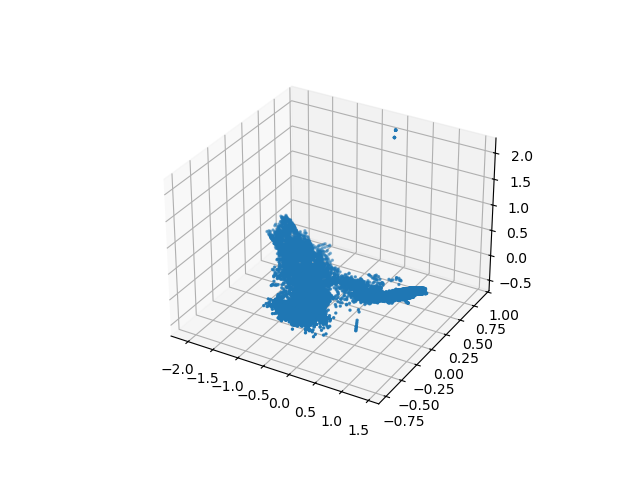

In [14]:
visualize_MDS_Graph(M,Z)

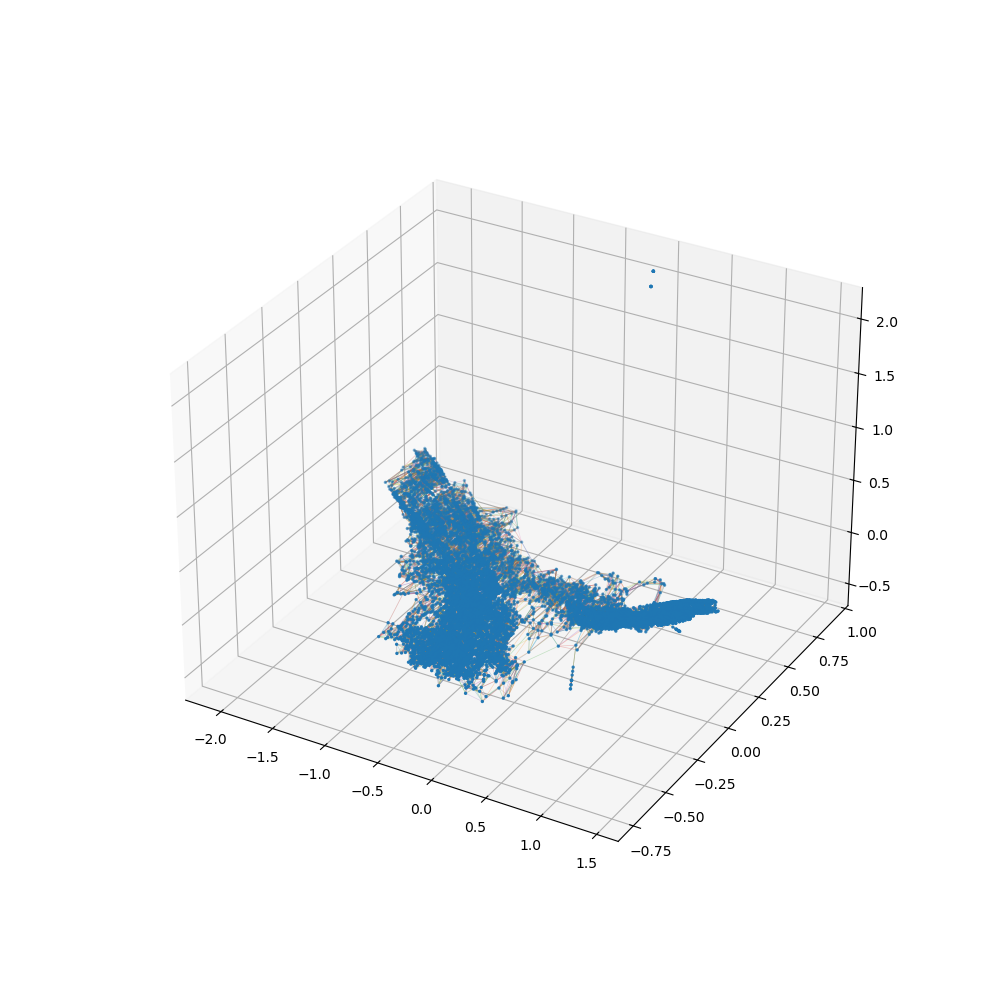

In [15]:
visualize_MDS_Graph_Edges(M, src, dst, Z)

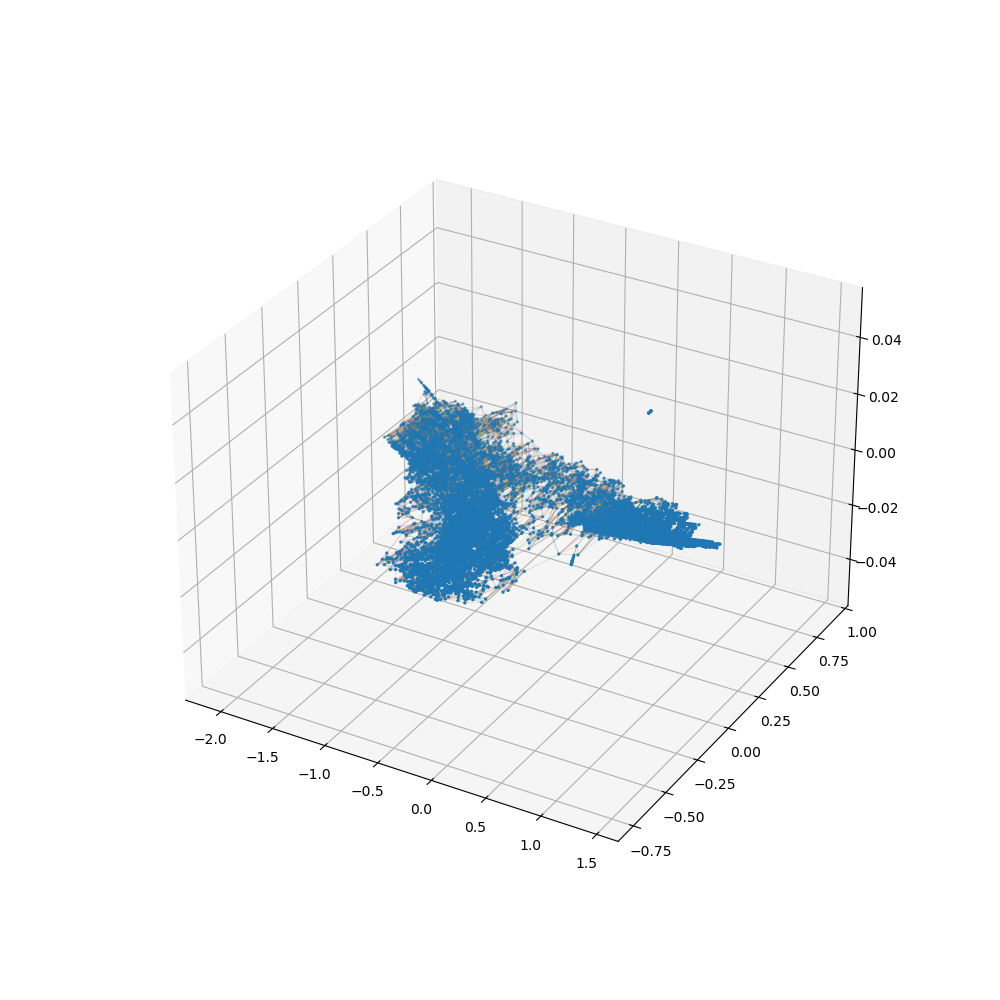

In [16]:
visualize_MDS_Graph_Edges_2D(M, src, dst, Z)

In [17]:
from Trajectory import * 

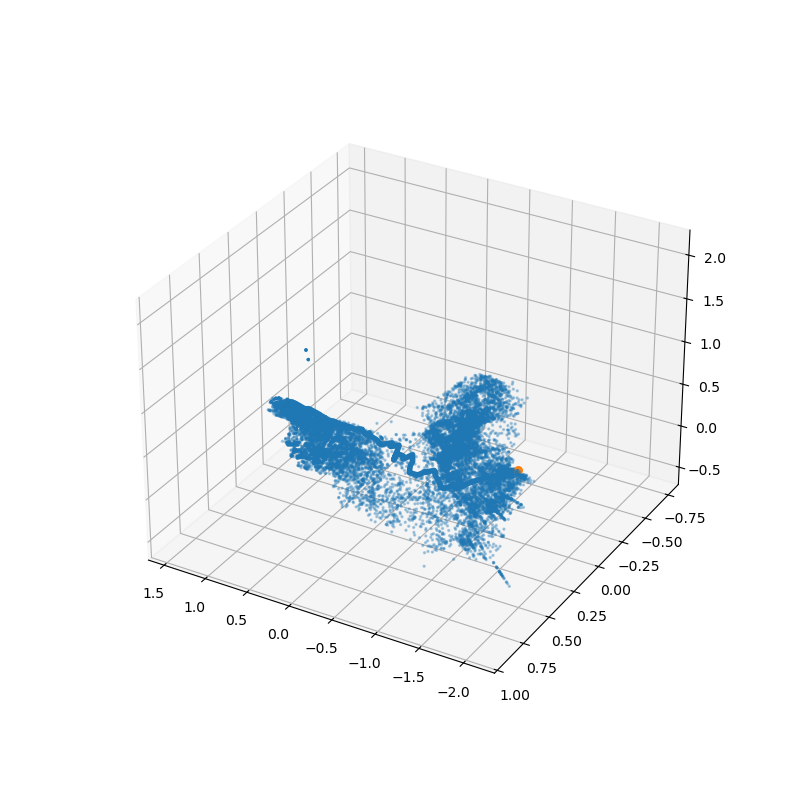

In [18]:
start_idx = np.argmin(wea)
end_idx = np.argmax(wea)

trajectory_points, trajectory_nodes = (
    build_weathering_trajectory(
        embedded=M,
        edge_src=src,
        edge_dst=dst,
        edge_weight=wei,
        start_idx=start_idx,
        end_idx=end_idx
    )
)

trajectory = resample_trajectory(
    trajectory_points,
    num_points=256
)

visualize_trajectory(M, trajectory)



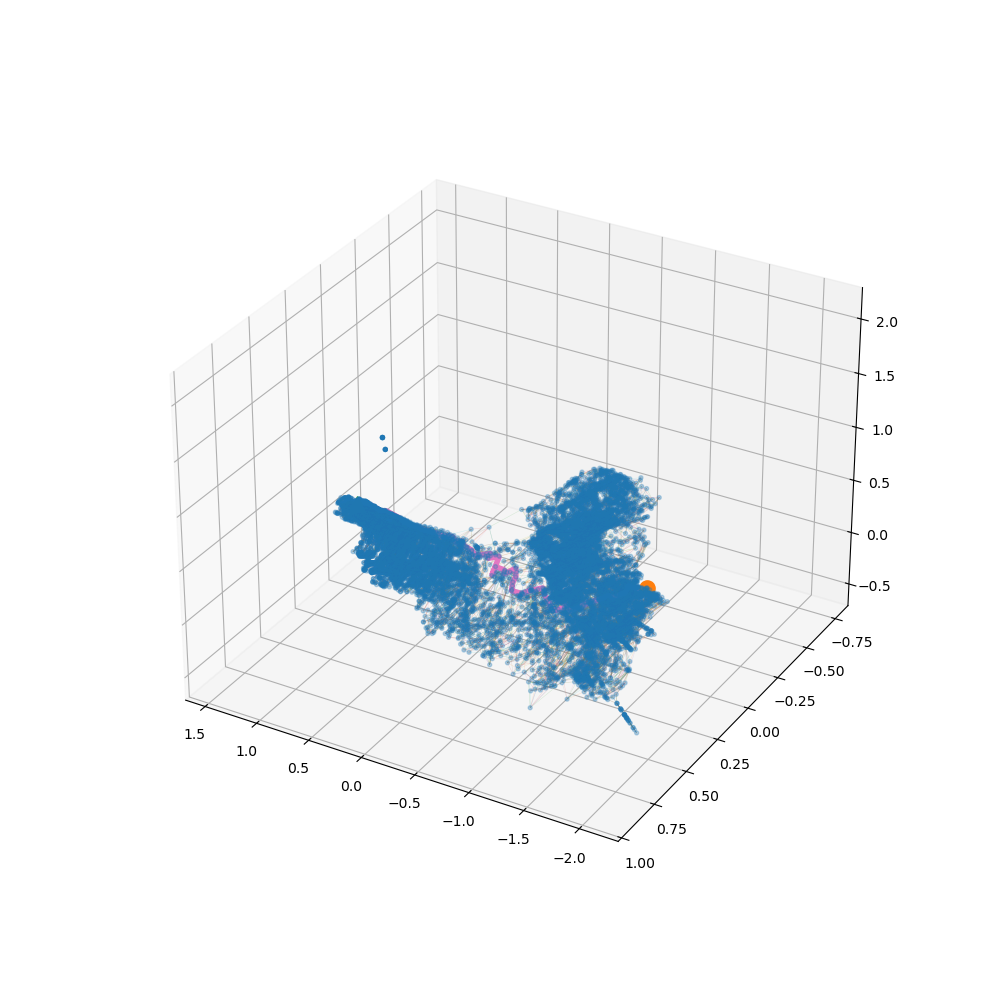

In [19]:
from Utility import visualize_MDS_Graph_With_Trajectory

visualize_MDS_Graph_With_Trajectory(
    Z=M,
    edge_src=src,
    edge_dst=dst,
    trajectory=trajectory
)